In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./data/train.csv')
print(df.shape)
print(df.head())

(439140, 16)
   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0      39.0         8       78.491         -7.564                  21.019   
1       7.0         4       75.095        -32.617                -223.207   
2      22.0        13       70.945         -7.540                -100.529   
3       2.0         7       94.361         -7.324                  -7.324   
4       6.0         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change  Pit

In [12]:
for stint in df["Stint"].unique():
    df_tyre_life = df[df["Stint"] == stint]["TyreLife"]
    print(df_tyre_life.head())

0     39.0
1      7.0
5     26.0
6     16.0
10    10.0
Name: TyreLife, dtype: float64
2     22.0
4      6.0
7      9.0
13    12.0
15    18.0
Name: TyreLife, dtype: float64
3      2.0
8      4.0
9      2.0
11    12.0
12     1.0
Name: TyreLife, dtype: float64
24     5.0
34     7.0
42    13.0
59    18.0
77    17.0
Name: TyreLife, dtype: float64
81      6.0
142     9.0
186     9.0
390     1.0
538    27.0
Name: TyreLife, dtype: float64
1384    10.0
1597     6.0
2245     4.0
2549    16.0
3764    14.0
Name: TyreLife, dtype: float64
3816     14.0
18330    14.0
37160    16.0
37550     6.0
53914     9.0
Name: TyreLife, dtype: float64
7998     15.0
30596    12.0
42129    16.0
42903    10.0
59189    16.0
Name: TyreLife, dtype: float64


In [18]:
from sklearn.preprocessing import MinMaxScaler
for stint in df["Stint"].unique():
    df.loc[df["Stint"] == stint, "Normalized_TyreLife"] = MinMaxScaler().fit_transform(df.loc[df["Stint"] == stint, ["TyreLife"]])
    #print(df.loc[df["Stint"] == stint, "Normalized_TyreLife"].head())

print(df[["Stint", "TyreLife", "Normalized_TyreLife"]].head())
print(df.head())

   Stint  TyreLife  Normalized_TyreLife
0      2      39.0             0.500000
1      2       7.0             0.078947
2      3      22.0             0.280000
3      1       2.0             0.013699
4      3       6.0             0.066667
   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0      39.0         8       78.491         -7.564                  21.019   
1       7.0         4       75.095        -32.617                -223.207   
2      22.0        13       70.945        

In [32]:
def normalize_tyre_life(x):
    x[["Normalized_TyreLife"]] = MinMaxScaler().fit_transform(x[["TyreLife"]])
    return x

In [ ]:

from sklearn.compose import make_column_transformer

ct = make_column_transformer(
    (MinMaxScaler(), ["TyreLife"]),
    remainder="passthrough"
) 

In [ ]:
def transform_normalize_tyre_life(x):
    x = ct.fit_transform(x[["TyreLife"]])
    return x 

In [87]:
df_tyre_life = df.groupby("Stint").apply(lambda x: normalize_tyre_life(x))
print(df_tyre_life.shape)

(439140, 17)


/tmp/ipykernel_7630/3161564619.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tyre_life = df.groupby("Stint").apply(lambda x: normalize_tyre_life(x))


In [99]:
df["Normalized_TyreLife"] = df.groupby("Stint")["TyreLife"].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
print(df.head())

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0      39.0         8       78.491         -7.564                  21.019   
1       7.0         4       75.095        -32.617                -223.207   
2      22.0        13       70.945         -7.540                -100.529   
3       2.0         7       94.361         -7.324                  -7.324   
4       6.0         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change  PitNextLap  Norm

In [5]:
df_tyre_life = df.groupby("Stint")
vals = {}
for stint, group in df_tyre_life:
    vals[stint] = (group["TyreLife"].min(), group["TyreLife"].max())
print(vals)

{1: (np.float64(1.0), np.float64(74.0)), 2: (np.float64(1.0), np.float64(77.0)), 3: (np.float64(1.0), np.float64(76.0)), 4: (np.float64(1.0), np.float64(72.0)), 5: (np.float64(1.0), np.float64(73.0)), 6: (np.float64(1.0), np.float64(51.0)), 7: (np.float64(1.0), np.float64(46.0)), 8: (np.float64(1.0), np.float64(28.0))}


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class GroupedMinMaxScaler(BaseEstimator, TransformerMixin):
    def __init__(self, group_col='Stint', target_col='TyreLife'):
        self.group_col = group_col
        self.target_col = target_col

    
    def fit(self, X, y=None):
        self.vals = {}
        for stint, group in X.groupby(self.group_col):
            self.vals[stint] = (group[self.target_col].min(), group[self.target_col].max())
        return self
    
    def transform(self, X):
        X = X.copy()
        # X['Normalized_TyreLife'] = X.groupby(self.group_col)[self.target_col].transform(
        #     lambda x: (x - x.min()) / (x.max() - x.min())
        # 
        for stint, (min_val, max_val) in self.vals.items():
            mask = X[self.group_col] == stint
            X.loc[mask, 'Normalized_TyreLife'] = (X.loc[mask, self.target_col] - min_val) / (max_val - min_val)
        return X
scaler = GroupedMinMaxScaler()
df_scaled = scaler.transform(df)
print(df_scaled.head())

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0      39.0         8       78.491         -7.564                  21.019   
1       7.0         4       75.095        -32.617                -223.207   
2      22.0        13       70.945         -7.540                -100.529   
3       2.0         7       94.361         -7.324                  -7.324   
4       6.0         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change  PitNextLap  Norm

In [2]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [ ]:
df.isnull().sum()

In [ ]:
df['Driver'].value_counts().plot(kind='bar')
plt.title('Distribution of Drivers')
plt.xlabel('Driver')
plt.ylabel('Count')
plt.show()

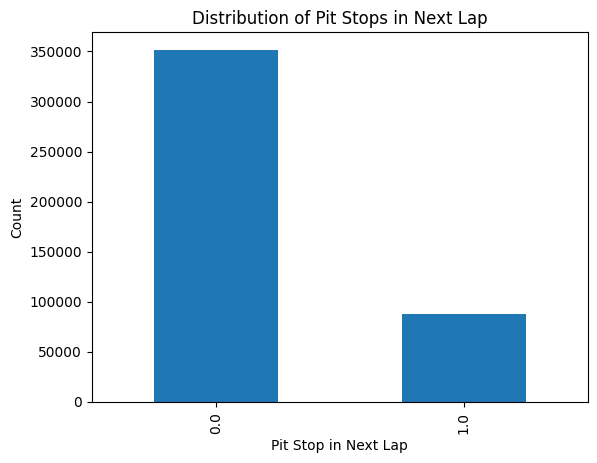

In [3]:
df['PitNextLap'].value_counts().plot(kind='bar')
plt.title('Distribution of Pit Stops in Next Lap')
plt.xlabel('Pit Stop in Next Lap')
plt.ylabel('Count')
plt.show()

In [4]:
df['Compound'].unique()

array(['HARD', 'MEDIUM', 'INTERMEDIATE', 'SOFT', 'WET'], dtype=object)

In [ ]:
df['PitNextLap'].values.shape

In [ ]:
from sklearn.preprocessing import TargetEncoder

te_D = TargetEncoder()
df['Driver_encoded'] = te_D.fit_transform(df['Driver'].values.reshape(-1, 1), df['PitNextLap'].values)
te_C = TargetEncoder()
df['Compound_encoded'] = te_C.fit_transform(df['Compound'].values.reshape(-1, 1), df['PitNextLap'].values)
te_R = TargetEncoder()
df['Race_encoded'] = te_R.fit_transform(df['Race'].values.reshape(-1, 1), df['PitNextLap'].values)
te_Y = TargetEncoder()
df['Year_encoded'] = te_Y.fit_transform(df['Year'].values.reshape(-1, 1), df['PitNextLap'].values)
df.head()

In [ ]:
df_train = df.drop(columns=['Driver', 'Compound', 'Race', 'Year', 'id', 'PitNextLap'])
X = df_train.values
y = df['PitNextLap'].values

In [ ]:
X_full = df.drop(columns=['id', 'PitNextLap'])
te_cols = ['Driver', 'Compound', 'Race', 'Year']
sc_cols = X_full.drop(columns=te_cols).columns
y = df['PitNextLap']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(class_weight='balanced', max_iter=3300, 
                                    learning_rate=0.1, max_depth=2, l2_regularization=10,
                                    loss='log_loss', random_state=1)
hgb.fit(X_train, y_train)
y_pred = hgb.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('te', TargetEncoder(categories='auto', target_type='binary', smooth='auto', cv=5, random_state=42), te_cols),
        ('sc', StandardScaler(), sc_cols)
    ]
)

pipe = Pipeline([('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(class_weight='balanced', max_iter=3300, 
                                                  learning_rate=0.1, max_depth=2, l2_regularization=10,
                                                  loss='log_loss', random_state=1))
])

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, X_full, y, cv=5, scoring='roc_auc')
for i, score in enumerate(scores):
    print(f'Fold {i+1}: AUC = {score:.4f}')
print(f'Mean AUC: {scores.mean():.4f}')

In [ ]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import numpy as np
def plot_confusion_matrix(y_pred, y_test):

    labels = np.unique(y_pred)
    confmat = confusion_matrix(y_test, y_pred, sample_weight=None, normalize=None)
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(confmat.shape[0]):
        for j in range(confmat.shape[1]):
            ax.text(x=j, y=i, s=confmat[i, j],
                va='center', ha='center')
            ax.xaxis.set_ticks_position('bottom')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

plot_confusion_matrix(y_pred, y_test)